In [ ]:
from fastopic import FASTopic
import pandas as pd
from sentence_splitter import split_text_into_sentences
from typing import List
import re
import glob
import os
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append("..")
from preprocessing import preprocess_report

In [4]:
full_df = pd.read_csv("../data/training_data/dataset__reports_subset_from_full_data_1_sentence_len_6__min_chunk_len_100__cos_thresh_0.4__nace_level_1__sample_ratio_1__filter_only_right_chunks_labeling/full_data.csv")
full_df

,Evaluation,Notes,text,Score,NACE_Code
0,NaN,NaN,codetermination rights play a key role in the ...,0.404949,J
1,NaN,NaN,as required by section of the companies act ac...,0.413243,J
2,NaN,NaN,. organize and keep the register of shareholde...,0.403249,J
3,NaN,NaN,a system for disseminating media content such ...,0.501952,J
4,NaN,NaN,b. the total holdings directly or indirectly o...,0.434005,J
...,...,...,...,...,...
59161,NaN,NaN,it is also noted that in ppa sa invested in ch...,0.546908,H
59162,NaN,NaN,downstream transportation and distribution sco...,0.496715,H
59163,NaN,NaN,the company has also established regulations s...,0.402236,H
59164,NaN,NaN,the company is required to make cash deposits ...,0.426031,H


In [6]:
new_df = []
for n_class in set(full_df["NACE_Code"].to_list()): 
    new_df.append(full_df[full_df["NACE_Code"] == n_class].iloc[:200])

In [10]:
#new_df = pd.concat(new_df)
full_df = new_df

In [11]:
docs = full_df["text"].to_list()

In [12]:
number_of_topics = len(set(full_df["NACE_Code"].to_list()))
number_of_topics

19

In [13]:
model = FASTopic(number_of_topics, verbose=True)

2025-11-06 09:31:40,023 - FASTopic - use device: cpu


In [14]:
model.fit(docs)

2025-11-06 09:31:40,128 - FASTopic - First fit the model.
parsing texts: 100%|██████████| 3630/3630 [00:00<00:00, 26045.78it/s]
/Users/hendrikweichel/miniconda3/envs/remedi/lib/python3.10/site-packages/sklearn/feature_extraction/text.py:517: UserWarning:

The parameter 'token_pattern' will not be used since 'tokenizer' is not None'

2025-11-06 09:31:42,500 - TopMost - Real vocab size: 14180
2025-11-06 09:31:42,501 - TopMost - Real training size: 3630 	 avg length: 43.150


Batches:   0%|          | 0/114 [00:00<?, ?it/s]

Training FASTopic: 100%|██████████| 200/200 [01:13<00:00,  2.73it/s]


Topic 0: leases accumulated classified biological rightofuse disposals probable useful properties capitalised recoverable landfill timber realisable reliably
Topic 1: resolution proceedings consent auditors delegated appointment thereof indirectly affiliates article concerning interested breach connected chapter
Topic 2: motor furniture leasehold fittings vehicles machinery fixtures terminal renovation explained car block containers increases amounting
Topic 3: reportable chief allocation segments decisions aggregated codm consists principally manages functions considers discussion maker articles
Topic 4: animal farming ecosystem animals like serve helps salmon species rural fish horticulture river kitchen steam
Topic 5: carta beverage restaurant packages casino beverages brand cargo guest consumers restaurants luxury stores gaming brands
Topic 6: medical healthcare nursing homes skilled hospital patients hospitals care patient living aged clinical wellness residents
Topic 7: settled b

In [ ]:
model.get_topic_weights()

array([0.03204773, 0.03118731, 0.03645261, 0.03041417, 0.04035737,
       0.0552747 , 0.07152434, 0.05491998, 0.06540225, 0.07922924,
       0.06851254, 0.03315929, 0.03294624, 0.03375414, 0.0320822 ,
       0.07118481, 0.03536965, 0.05603489, 0.07501642, 0.03228518,
       0.03284498], dtype=float32)

## Test it for new Reports

In [ ]:
new_reports = glob.glob('/Users/hendrikweichel/projects/NaceCodeClassification/nace_report_topic_analysis_3/data/TEXT_stoxx600_docling/test_reports/*.txt')
new_reports

['/Users/hendrikweichel/projects/NaceCodeClassification/nace_report_topic_analysis_3/data/TEXT_stoxx600_docling/test_reports/Bureau-Veritas_Universal_Registration_Document_2022_13.7Mo.txt',
 '/Users/hendrikweichel/projects/NaceCodeClassification/nace_report_topic_analysis_3/data/TEXT_stoxx600_docling/test_reports/2022 HOCHTIEF Konzernbericht.txt',
 '/Users/hendrikweichel/projects/NaceCodeClassification/nace_report_topic_analysis_3/data/TEXT_stoxx600_docling/test_reports/Barclays-PLC-Annual-Report-2022-3.txt',
 '/Users/hendrikweichel/projects/NaceCodeClassification/nace_report_topic_analysis_3/data/TEXT_stoxx600_docling/test_reports/swisscom_geschaeftsbericht_gesamt_2022_de.txt',
 '/Users/hendrikweichel/projects/NaceCodeClassification/nace_report_topic_analysis_3/data/TEXT_stoxx600_docling/test_reports/groupe-adp-urd-2023-en.txt']

In [ ]:
df_stoxx = pd.read_excel("/Users/hendrikweichel/projects/NaceCodeClassification/nace_report_topic_analysis_3/data/PDF_stoxx600/STOXX600_as_of_2025_03_13.xlsx")
df_stoxx

,Name,Symbol,FactSet ID,Revenue - 2022 (in EUR),Revenue - 2023 (in EUR),Revenue - 2024 (in EUR),NACE,NACE_letter,Report
0,Brenntag SE,BNR-DE,BNR-DE,19429.300000,16815.100000,NaN,46.73,G,Brenntag Societas Europaea1.pdf
1,Grafton Group Plc,GFTU-GB,GFTU-GB,2697.420700,2666.632525,NaN,47.52,G,Grafton Group Plc1.pdf
2,LANXESS AG,LXS-DE,LXS-DE,8088.000000,6714.000000,NaN,20.59,C,LANXESS AG1.pdf
3,Banco de Sabadell SA,SAB-ES,SAB-ES,6927.920000,10467.899000,11656.548000,64.19,K,Banco de Sabadell SA1.pdf
4,freenet AG,FNTN-DE,FNTN-DE,2556.714000,2627.300000,NaN,61.20,J,freenet AG1.pdf
...,...,...,...,...,...,...,...,...,...
595,Syensqo SA/NV,SYENS-BE,SYENS-BE,7890.000000,6834.000000,6563.000000,72.11,M,NaN
596,Galderma Group AG,GALD-CH,GALD-CH,3577.917927,3775.451846,4076.950861,21.20,C,NaN
597,"Puig Brands, S.A. Class B",PUIG-ES,PUIG-ES,3619.603000,4304.067000,4789.779000,20.42,C,NaN
598,CVC Capital Partners plc,CVC-NL,CVC-NL,1054.827000,1153.785000,NaN,66.30,K,NaN


Batches: 100%|██████████| 90/90 [00:15<00:00,  5.86it/s]


Topic 0: articles decree legislative des bis paragraph french opinion pursuant association cnc mandates dated media january
Topic 1: und agricultural region zur auf bei der von veolia wir checked prysmian landwirtschaft aus fasb
Topic 2: board members expertise supervisory committee manager governance platform culture updates topics committees courses advisory experience
Topic 3: list prepared anglo indicators american estimates south thresholds jorc samrec stated report considering figures disclosures
Topic 4: employees care wellbeing occupational personnel staff leave mental employed healthcare assistance nursing employment workplace positions
Topic 5: taxonomy taxonomyeligible delegated taxonomyaligned undertakings eligibility turnover eligible capex interpretation annex expenditures opex nonfinancial aligned
Topic 6: property lease estate real leases properties rental rightofuse hotel leased car lessee accommodation lessor depreciation
Topic 7: human guidelines comply laws duties c

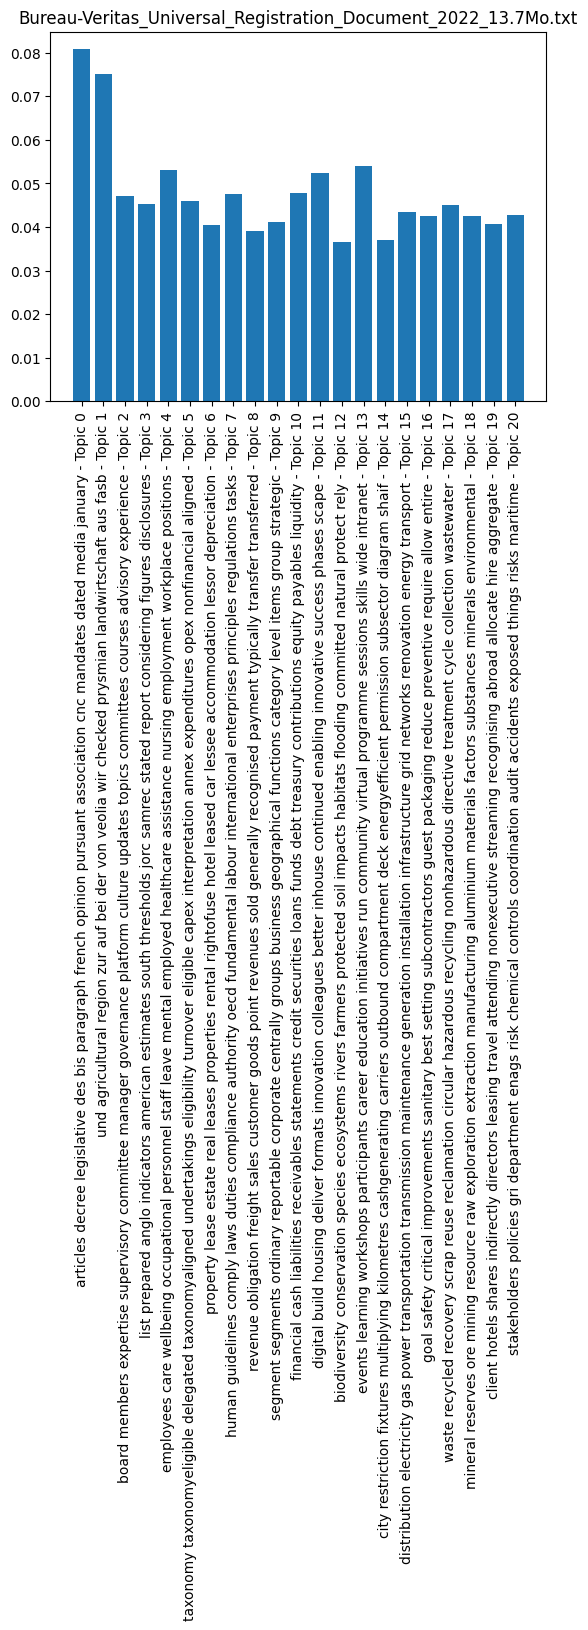

Batches: 100%|██████████| 90/90 [00:13<00:00,  6.81it/s]


Topic 0: articles decree legislative des bis paragraph french opinion pursuant association cnc mandates dated media january
Topic 1: und agricultural region zur auf bei der von veolia wir checked prysmian landwirtschaft aus fasb
Topic 2: board members expertise supervisory committee manager governance platform culture updates topics committees courses advisory experience
Topic 3: list prepared anglo indicators american estimates south thresholds jorc samrec stated report considering figures disclosures
Topic 4: employees care wellbeing occupational personnel staff leave mental employed healthcare assistance nursing employment workplace positions
Topic 5: taxonomy taxonomyeligible delegated taxonomyaligned undertakings eligibility turnover eligible capex interpretation annex expenditures opex nonfinancial aligned
Topic 6: property lease estate real leases properties rental rightofuse hotel leased car lessee accommodation lessor depreciation
Topic 7: human guidelines comply laws duties c

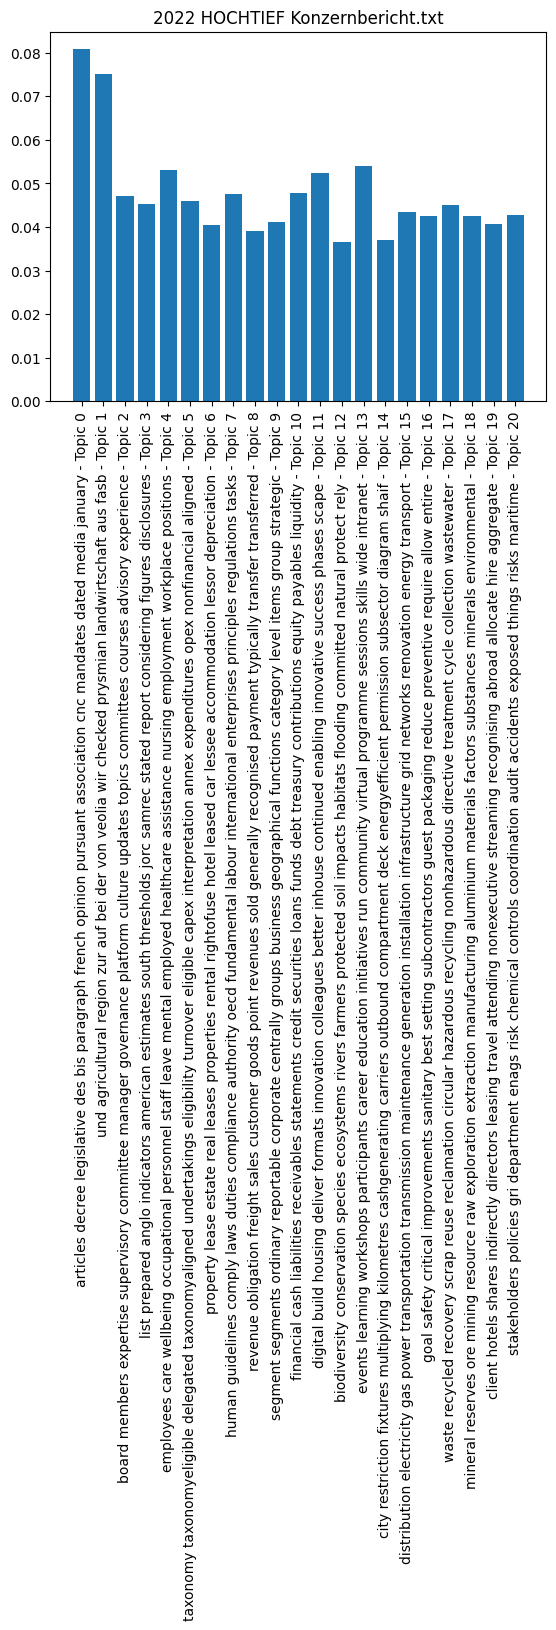

Batches: 100%|██████████| 90/90 [00:15<00:00,  6.00it/s]


Topic 0: articles decree legislative des bis paragraph french opinion pursuant association cnc mandates dated media january
Topic 1: und agricultural region zur auf bei der von veolia wir checked prysmian landwirtschaft aus fasb
Topic 2: board members expertise supervisory committee manager governance platform culture updates topics committees courses advisory experience
Topic 3: list prepared anglo indicators american estimates south thresholds jorc samrec stated report considering figures disclosures
Topic 4: employees care wellbeing occupational personnel staff leave mental employed healthcare assistance nursing employment workplace positions
Topic 5: taxonomy taxonomyeligible delegated taxonomyaligned undertakings eligibility turnover eligible capex interpretation annex expenditures opex nonfinancial aligned
Topic 6: property lease estate real leases properties rental rightofuse hotel leased car lessee accommodation lessor depreciation
Topic 7: human guidelines comply laws duties c

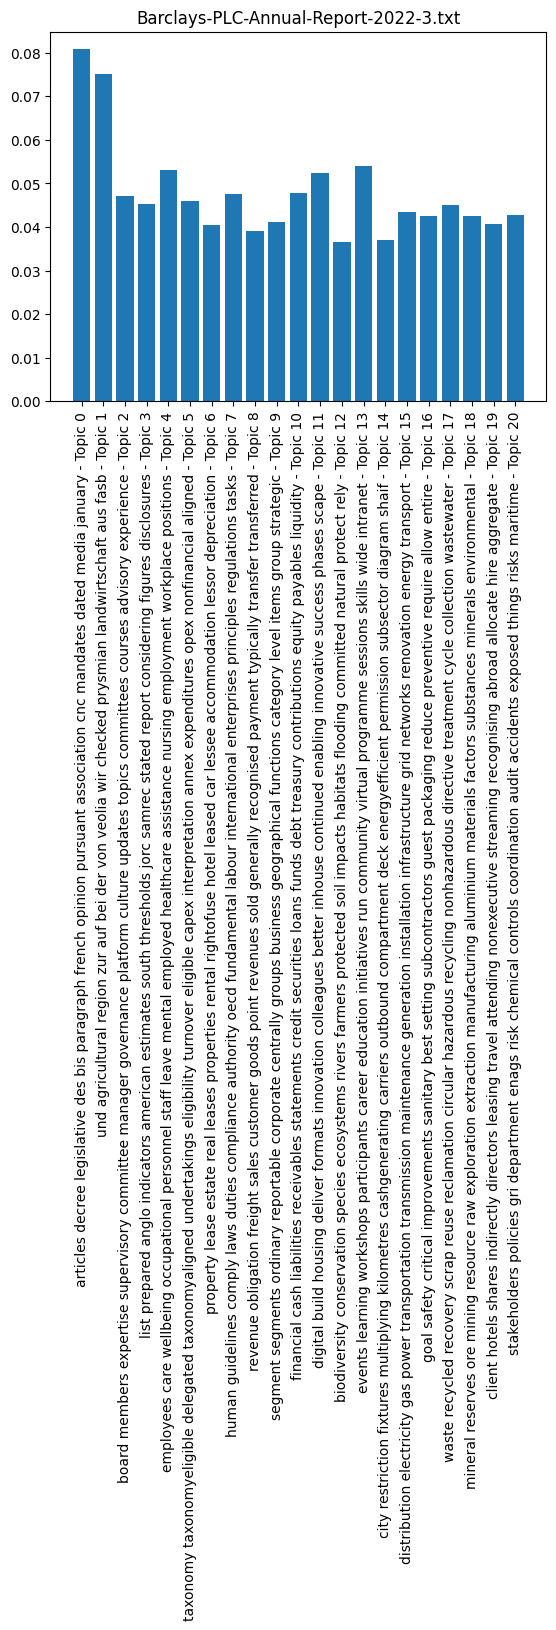

Batches: 100%|██████████| 90/90 [00:17<00:00,  5.18it/s]


Topic 0: articles decree legislative des bis paragraph french opinion pursuant association cnc mandates dated media january
Topic 1: und agricultural region zur auf bei der von veolia wir checked prysmian landwirtschaft aus fasb
Topic 2: board members expertise supervisory committee manager governance platform culture updates topics committees courses advisory experience
Topic 3: list prepared anglo indicators american estimates south thresholds jorc samrec stated report considering figures disclosures
Topic 4: employees care wellbeing occupational personnel staff leave mental employed healthcare assistance nursing employment workplace positions
Topic 5: taxonomy taxonomyeligible delegated taxonomyaligned undertakings eligibility turnover eligible capex interpretation annex expenditures opex nonfinancial aligned
Topic 6: property lease estate real leases properties rental rightofuse hotel leased car lessee accommodation lessor depreciation
Topic 7: human guidelines comply laws duties c

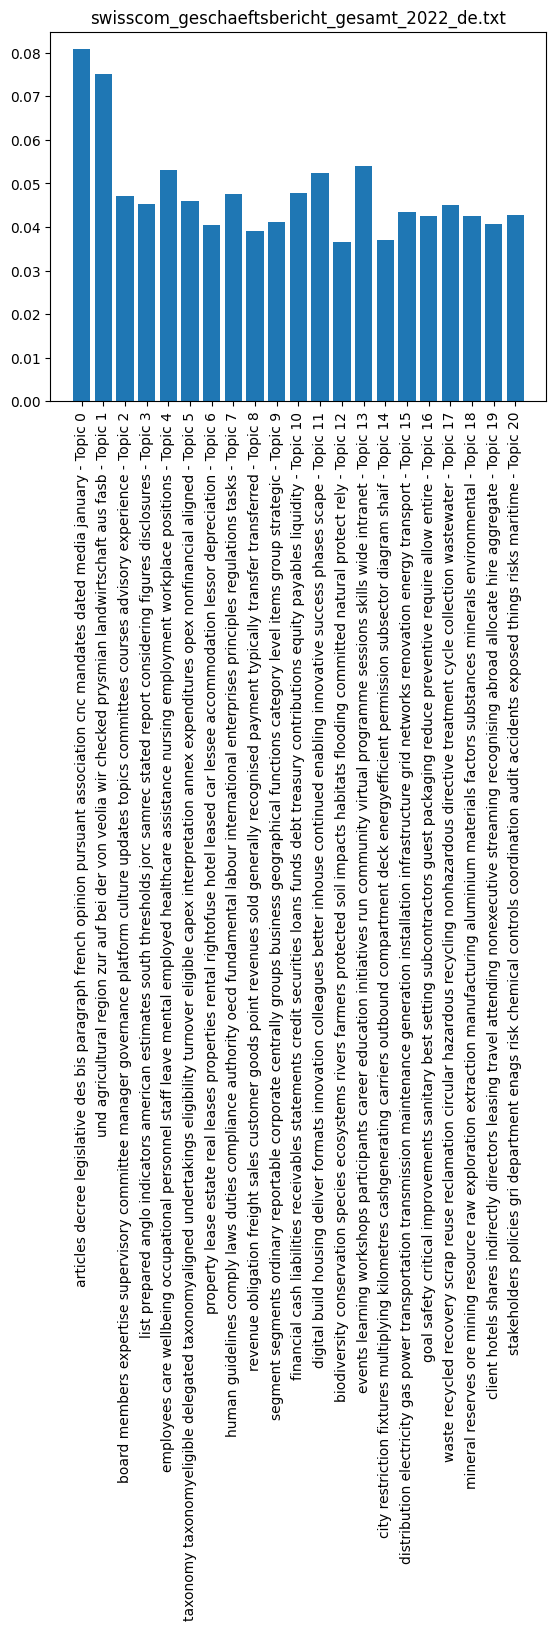

Batches: 100%|██████████| 90/90 [00:18<00:00,  4.85it/s]


Topic 0: articles decree legislative des bis paragraph french opinion pursuant association cnc mandates dated media january
Topic 1: und agricultural region zur auf bei der von veolia wir checked prysmian landwirtschaft aus fasb
Topic 2: board members expertise supervisory committee manager governance platform culture updates topics committees courses advisory experience
Topic 3: list prepared anglo indicators american estimates south thresholds jorc samrec stated report considering figures disclosures
Topic 4: employees care wellbeing occupational personnel staff leave mental employed healthcare assistance nursing employment workplace positions
Topic 5: taxonomy taxonomyeligible delegated taxonomyaligned undertakings eligibility turnover eligible capex interpretation annex expenditures opex nonfinancial aligned
Topic 6: property lease estate real leases properties rental rightofuse hotel leased car lessee accommodation lessor depreciation
Topic 7: human guidelines comply laws duties c

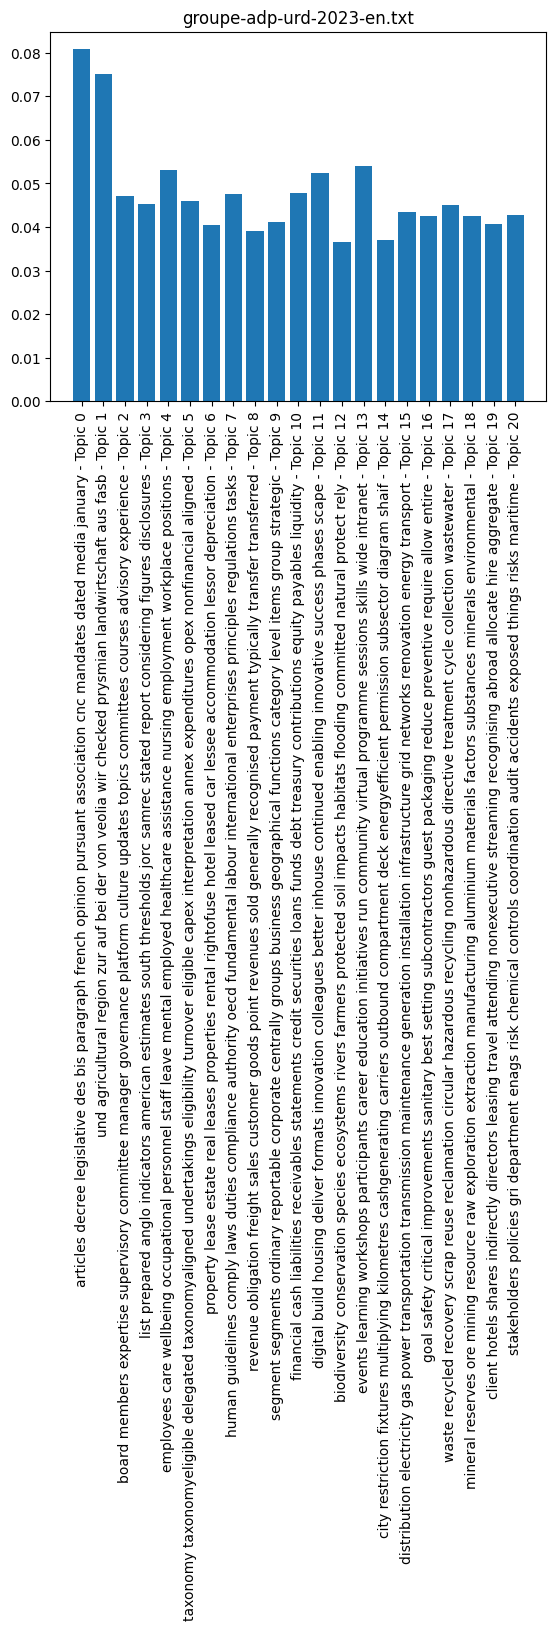

In [ ]:
docs_results = {}
for report in new_reports: 
    new_docs = preprocess_report('/Users/hendrikweichel/projects/NaceCodeClassification/nace_report_topic_analysis_3/data/TEXT_stoxx600_docling/test_reports/2022 HOCHTIEF Konzernbericht.txt')
    doc_topic_dist = model.transform(new_docs)
    docs_results[report] = doc_topic_dist
    topic_desc = [f"{word} - Topic {i}" for i, word in enumerate(model.get_top_words())]
    plt.bar(topic_desc, doc_topic_dist.mean(0))
    plt.xticks(rotation=90)
    plt.title(os.path.basename(report))
    plt.show()

In [ ]:
doc_topic_dist.shape

(2868, 21)

In [ ]:
doc_topic_dist

array([[0.06199033, 0.05767304, 0.03667448, ..., 0.04886733, 0.03680421,
        0.03904716],
       [0.07343416, 0.06442501, 0.06585549, ..., 0.04644047, 0.03529663,
        0.04433136],
       [0.05735443, 0.07324256, 0.04862537, ..., 0.04907188, 0.03711066,
        0.0355358 ],
       ...,
       [0.06895676, 0.03968818, 0.04946714, ..., 0.03085956, 0.04019222,
        0.03105179],
       [0.06217108, 0.05939882, 0.04361559, ..., 0.05648794, 0.02883018,
        0.04158193],
       [0.05496573, 0.04066794, 0.0437686 , ..., 0.03070405, 0.05086392,
        0.03772695]], dtype=float32)